In [1]:
import numpy as np
import matplotlib.pyplot as plt
from src.least_squares import LinearRegression, PowerLawRegression
from src.SGD import SGD, NoisyGD
from scheduled import WSDSchedule, ConstantSchedule
from src.new_schedules.polynomial import PolynomialSchedule
from src.compute import Computations

In [2]:
T=100
sigma = 0.1
dim = 10

eta = 0.01

model = PowerLawRegression(dim=dim, sigma=sigma, exponent=2)

wsd = WSDSchedule(steps=T, base_lr=eta, cooldown_len=0.4)
constant = ConstantSchedule(steps=T, base_lr=eta)
polynomial = PolynomialSchedule(steps=T, base_lr=eta, exponent=0.5)

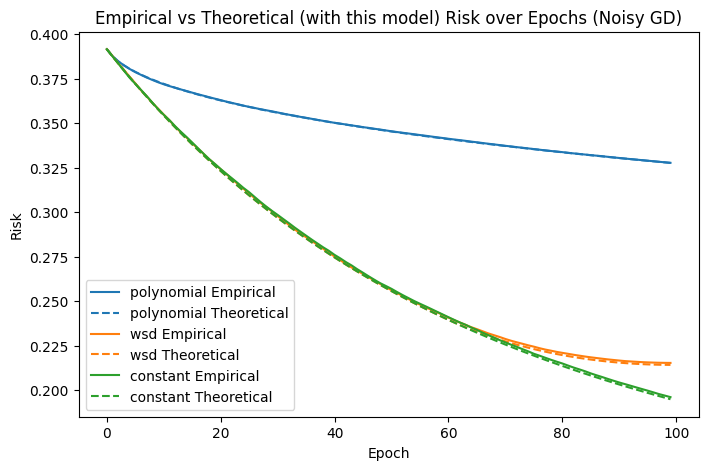

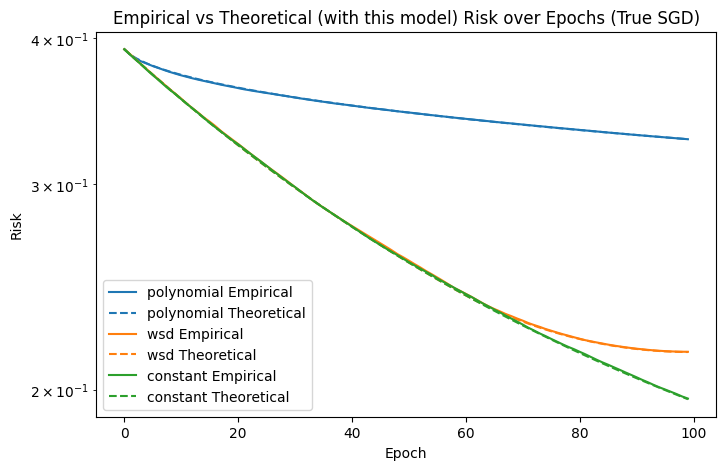

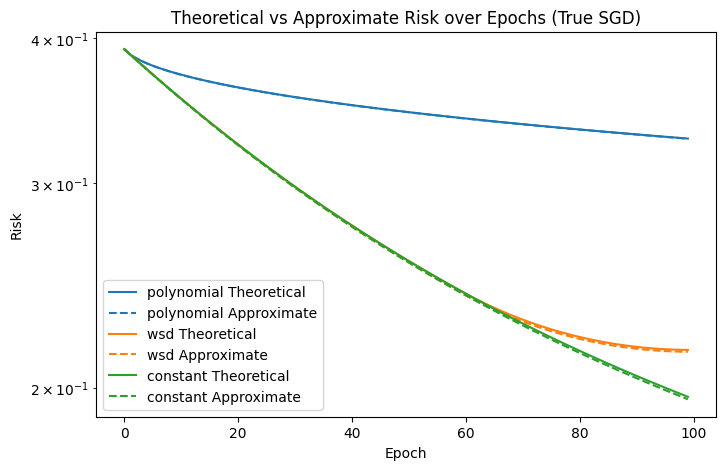

In [5]:
n = 1000
x0 = np.random.multivariate_normal(np.zeros(dim), np.eye(dim))

computations_noisyGD = Computations(model, schedules=[polynomial, wsd, constant], sgd_class=NoisyGD)
computations_SGD = Computations(model, schedules=[polynomial, wsd, constant], sgd_class=SGD)

#empirical = computations_noisyGD.compute_all_empirical_risks(x0, n_runs=n, plot=True)
#theoretical = computations_noisyGD.compute_all_theoretical_risks(x0, plot=True)
#empirical_SGD = computations_SGD.compute_all_empirical_risks(x0, n_runs=n, plot=True)
#theoretical_SGD = computations_SGD.compute_all_theoretical_risks(x0, plot=True)

risksNoisy = computations_noisyGD.compute_all_risks(x0, n_runs=n, plot=True)
risksSGD = computations_SGD.compute_all_risks(x0, n_runs=n, plot=True, log_scale=True)
approx_vs_theoretical = computations_SGD.compute_approx_vs_theoretical_risks(x0, plot=True, log_scale=True)

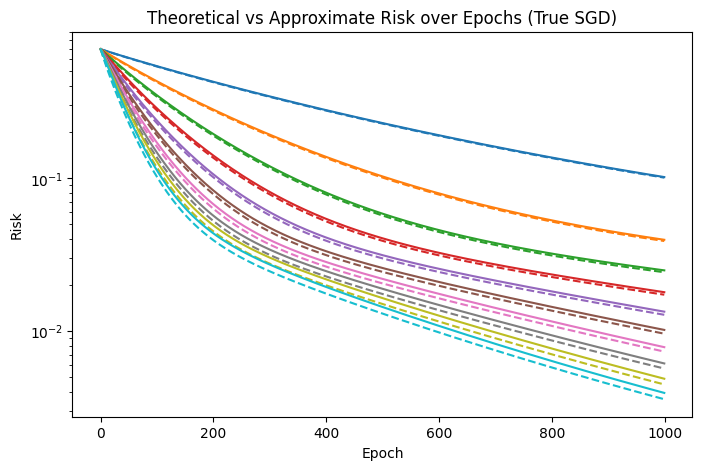

In [4]:
n = 100
x0 = np.random.multivariate_normal(np.zeros(dim), np.eye(dim))
T = 1000

schedules = [ConstantSchedule(steps=T, base_lr=eta) for eta in np.linspace(0.01, 0.1, num=10)]
schedules_names = [f"ConstantSchedule(eta={eta:.2f})" for eta in np.linspace(0.01, 0.1, num=10)]
computations_SGD_many = Computations(model, schedules=schedules, schedules_names=schedules_names, sgd_class=SGD)
all = computations_SGD_many.compute_approx_vs_theoretical_risks(x0,  plot=True, log_scale=True, legend=False)
